In [1]:
import json
import os
from datetime import timedelta
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (mean_squared_error,
                             r2_score, mean_absolute_error,
                             mean_absolute_percentage_error)
from numpy import sqrt



In [2]:

df_new = pd.read_csv("/home/patrick/Desktop/Projects/time-series-analysis/Notebooks/Part 2/price_weather_df.v2.csv", index_col=0, parse_dates=True)
df_new

,Alface Americana - Roça,Alface Crespa - Roça,Alface Lisa - Roça,Alface Americana - Atacado,Alface Crespa - Atacado,PREC_HOR_max,PREC_HOR_min,PREC_HOR_sum,PREC_HOR_mean,PREC_HOR_max_ra4,...,VENT_VEL_HOR_max,VENT_VEL_HOR_min,VENT_VEL_HOR_sum,VENT_VEL_HOR_mean,VENT_VEL_HOR_max_ra4,VENT_VEL_HOR_min_ra4,VENT_VEL_HOR_sum_ra4,VENT_VEL_HOR_mean_ra4,VENT_VEL_HOR_mean_ra4_shift8,VENT_VEL_HOR_mean_ra4_shift8_diff
dt,,,,,,,,,,,,,,,,,,,,,
2016-06-26 00:00:00+00:00,0.944167,0.777778,0.777778,NaN,NaN,5.8,0.0,16.0,0.095238,8.30,...,2.6,0.0,46.500000,0.276786,2.900000,0.000000,52.625000,0.313244,0.241667,0.099256
2016-07-03 00:00:00+00:00,0.847083,0.588056,0.588056,NaN,NaN,0.0,0.0,0.0,0.000000,3.00,...,1.6,0.0,11.100000,0.066071,2.350000,0.000000,30.650000,0.182440,0.264881,0.023214
2016-07-10 00:00:00+00:00,0.750000,0.398333,0.398333,NaN,NaN,0.0,0.0,0.0,0.000000,1.50,...,3.3,0.0,94.900000,0.564881,2.550000,0.000000,49.600000,0.295238,0.299554,0.034673
2016-07-17 00:00:00+00:00,0.750000,0.388889,0.426111,NaN,NaN,2.2,0.0,9.4,0.055952,2.00,...,3.2,0.0,52.400000,0.311905,2.675000,0.000000,51.225000,0.304911,0.392708,0.093155
2016-07-24 00:00:00+00:00,0.777500,0.370556,0.370556,NaN,NaN,1.0,0.0,10.4,0.061905,0.80,...,3.3,0.0,38.700000,0.230357,2.850000,0.000000,49.275000,0.293304,0.348958,-0.043750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-11-26 00:00:00+00:00,2.375000,1.225000,1.225000,1.0,0.5,20.2,0.0,111.4,0.663095,26.60,...,5.2,0.3,482.621965,2.872750,2.553191,0.414362,270.056881,1.607481,1.561245,-0.464673
2023-12-03 00:00:00+00:00,1.875000,0.750000,0.750000,1.0,0.5,5.2,0.0,13.0,0.077381,10.20,...,4.3,0.1,216.900000,1.291071,3.300000,0.364362,283.746543,1.688968,0.943769,-0.617476
2023-12-10 00:00:00+00:00,1.458333,0.677083,0.677083,1.0,0.5,28.2,0.0,117.2,0.697619,17.20,...,2.0,0.2,165.100000,0.982738,3.425000,0.250000,268.984309,1.601097,0.731297,-0.212472


array([<Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>],
      dtype=object)

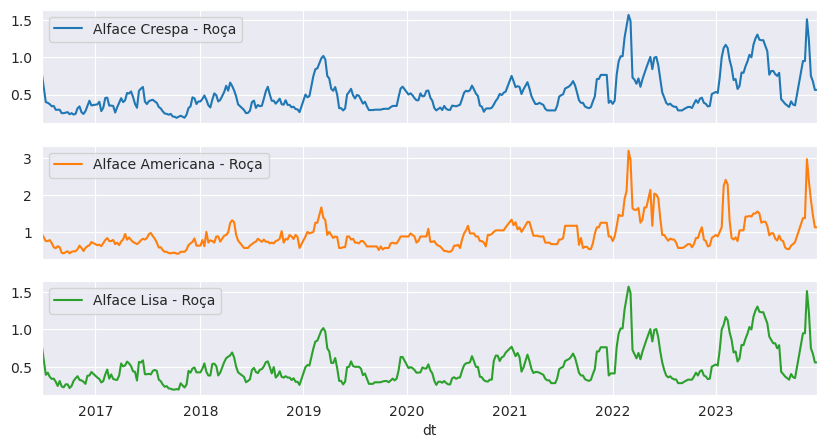

In [8]:
#plot Alface series in one chart vertically
df_new[['Alface Crespa - Roça', 'Alface Americana - Roça', 'Alface Lisa - Roça']].plot(subplots=True, figsize=(10, 5))

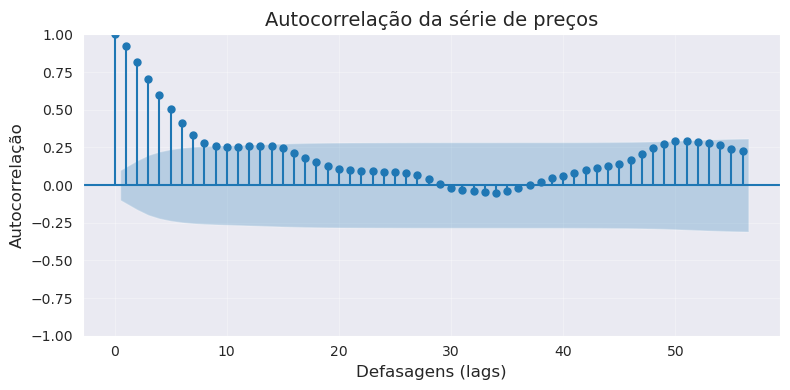

In [18]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(8, 4))

plot_acf(df_new['Alface Crespa - Roça'], lags=56, ax=ax)

# Ajustes visuais
ax.set_title('Função de Autocorrelação (ACF) - Alface Crespa', fontsize=14)
ax.set_xlabel('Defasagens (lags)', fontsize=12)
ax.set_ylabel('Autocorrelação', fontsize=12)
ax.tick_params(axis='both', labelsize=10)

# Ajustar grid
ax.grid(alpha=0.3)

# Remover título interno automático do plot_acf
ax.set_title('Autocorrelação da série de preços', fontsize=14)

plt.tight_layout()

# Salvar em alta resolução
plt.savefig('acf_alface_crespa.pdf', dpi=300, bbox_inches='tight')
plt.show()

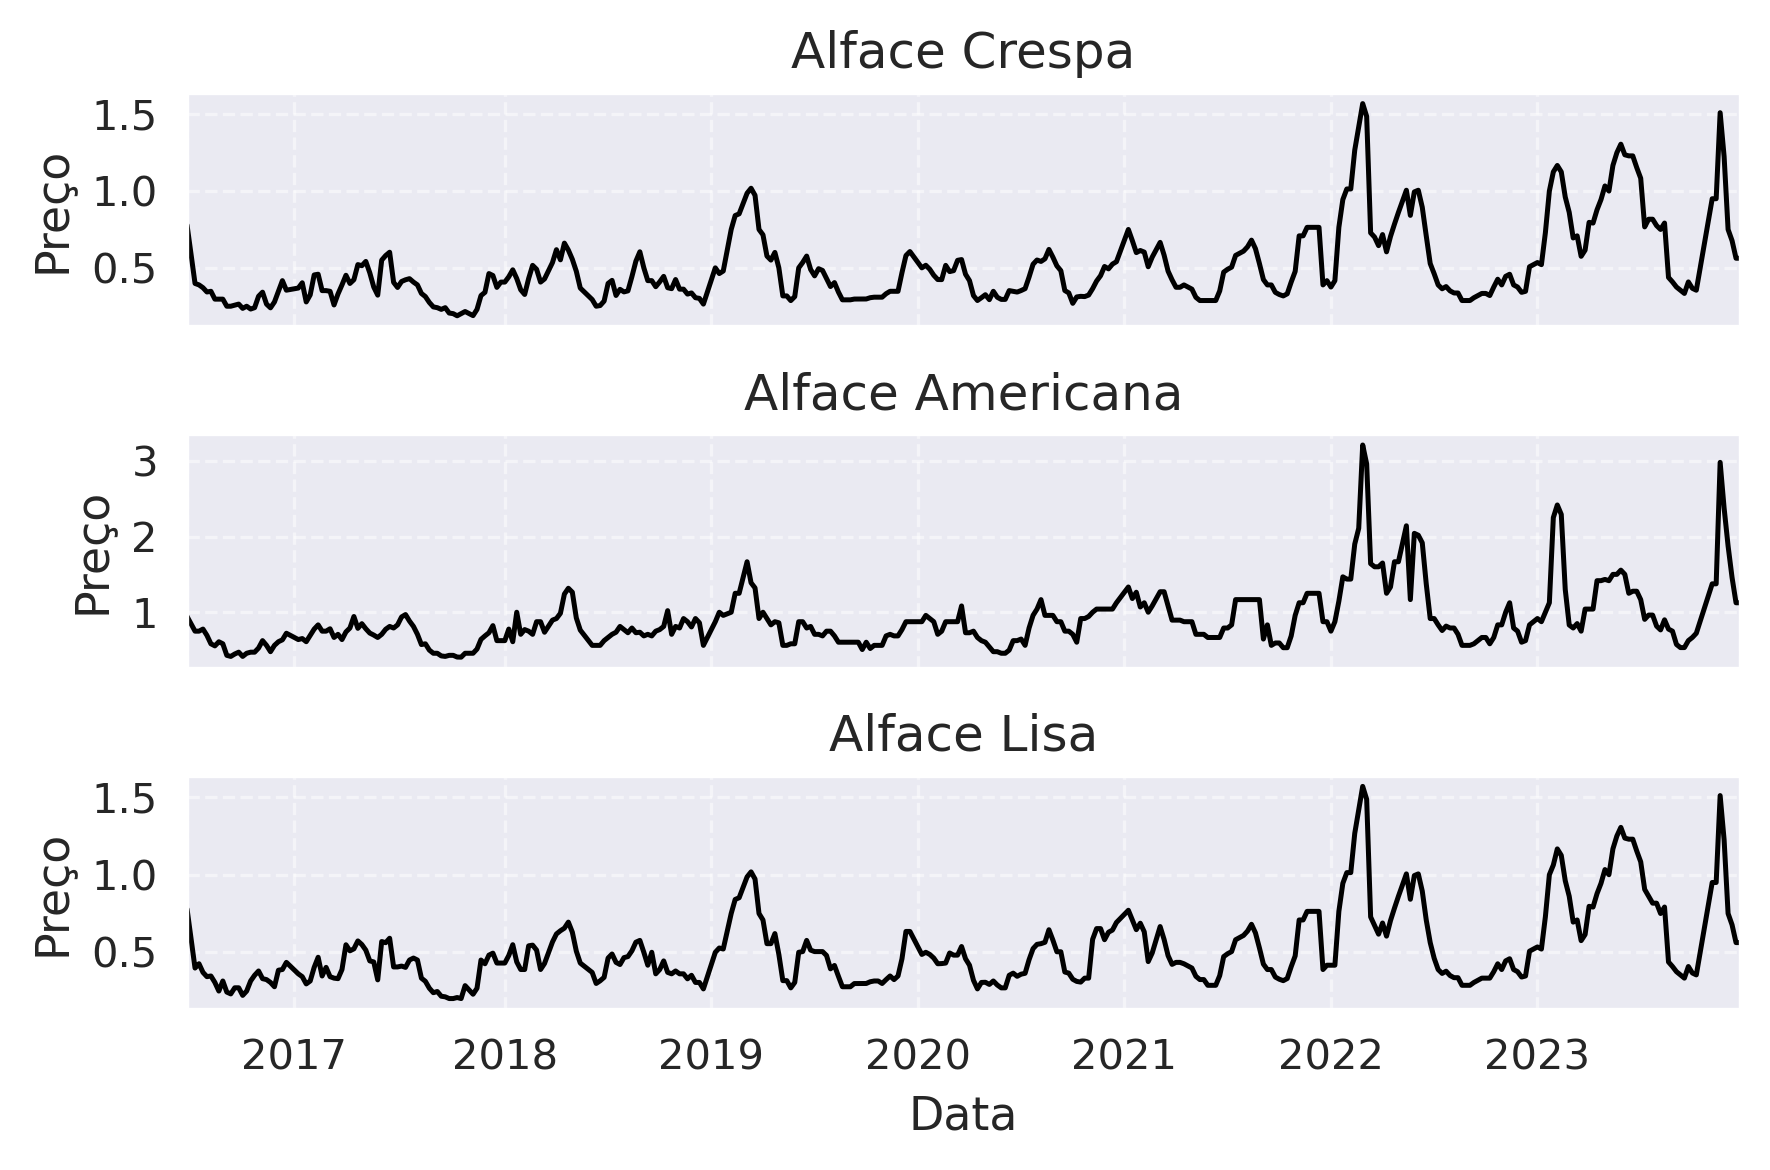

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 4), dpi=300, sharex=True)

series = ['Alface Crespa - Roça', 'Alface Americana - Roça', 'Alface Lisa - Roça']
titles = ['Alface Crespa', 'Alface Americana', 'Alface Lisa']

for ax, col, title in zip(axes, series, titles):
    df_new[col].plot(ax=ax, color='black', linewidth=1.2)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Preço', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)

axes[-1].set_xlabel('Data', fontsize=11)

plt.tight_layout()
plt.show()

In [50]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_vif(df):
    """
    Calculate VIF for each feature in the DataFrame.
    """
    X = sm.add_constant(df)
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif.drop(index=0)  # drop constant

def remove_high_vif(df, threshold=10, verbose=True):
    """
    Iteratively remove features with high VIF until all are below threshold.

    Parameters:
    - df: pandas DataFrame with features
    - threshold: VIF threshold (default=10)
    - verbose: print removal steps

    Returns:
    - cleaned_df: DataFrame with reduced multicollinearity
    """
    features = df.copy()

    while True:
        vif_df = calculate_vif(features)
        max_vif = vif_df["VIF"].max()

        if max_vif <= threshold:
            if verbose:
                print("✅ All VIF values are below the threshold.")
            break

        # Get variable with highest VIF
        worst_feature = vif_df.sort_values("VIF", ascending=False).iloc[0]["Variable"]

        if verbose:
            print(f"Removing '{worst_feature}' (VIF={max_vif:.2f})")

        # Drop the feature with highest VIF
        features = features.drop(columns=[worst_feature])

    return features

def plot_vif(vif_df, highlight=None, heihght=4):
    """
    Plot VIF values as a horizontal bar chart in a sober, publication-ready style.
    highlight: variable name to highlight (optional)
    """
    # Set style for scientific plots
    sns.set_theme(style="whitegrid", font="sans-serif"

                  )

    # Define color palette
    base_color = sns.color_palette("muted")[0]
    highlight_color = "#D62728"  # muted red

    # Create figure
    plt.figure(figsize=(8, heihght))

    # Plot bars
    bars = sns.barplot(x="VIF", y="Variable", data=vif_df,
                       color=base_color, saturation=0.8)

    # Highlight specific variable if needed
    if highlight and highlight in vif_df["Variable"].values:
        idx = vif_df.index[vif_df["Variable"] == highlight][0]
        bars.patches[idx].set_color(highlight_color)

    # Remove spines for clean look
    sns.despine()

    # # Add value labels for clarity
    # for bar in bars.patches:
    #     plt.text(bar.get_width() + 0.05,  # position slightly after bar
    #              bar.get_y() + bar.get_height()/2,
    #              f"{bar.get_width():.2f}",
    #              va='center', ha='left', fontsize=10)

    # Titles and labels
    plt.title("Variance Inflation Factor (VIF)", pad=15, fontweight="bold")
    plt.xlabel("VIF")
    plt.ylabel("Variable")

    plt.tight_layout()
    plt.show()

/home/patrick/miniconda3/envs/time-series-analysis2/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


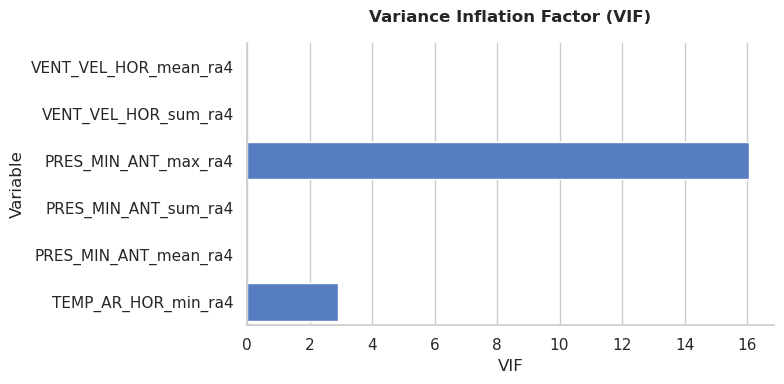

/home/patrick/miniconda3/envs/time-series-analysis2/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


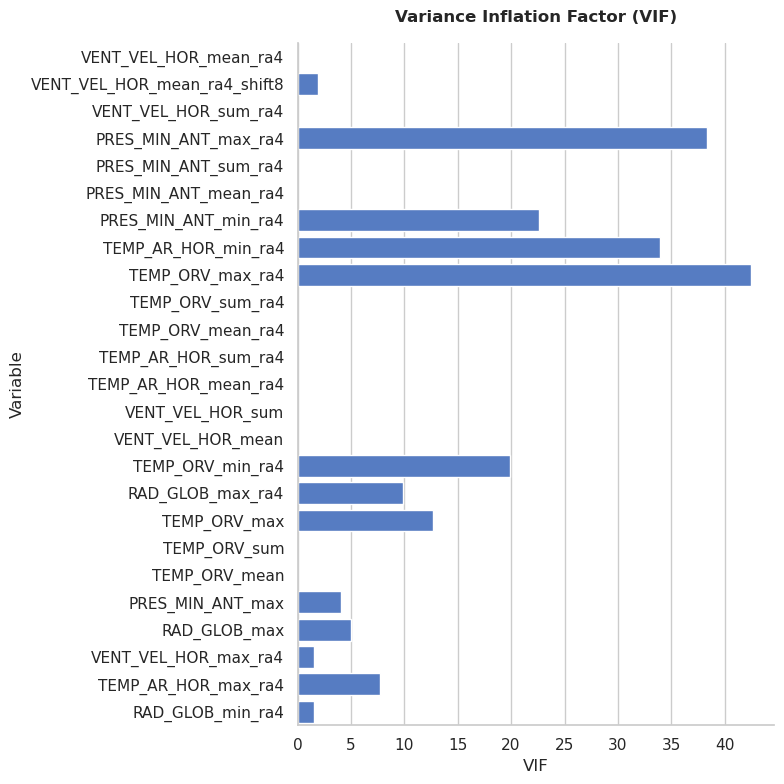

In [54]:
variaveis = [
    "VENT_VEL_HOR_mean_ra4",
    "VENT_VEL_HOR_mean_ra4_shift8",
    "VENT_VEL_HOR_sum_ra4",
    "PRES_MIN_ANT_max_ra4",
    "PRES_MIN_ANT_sum_ra4",
    "PRES_MIN_ANT_mean_ra4",
    "PRES_MIN_ANT_min_ra4",
    "TEMP_AR_HOR_min_ra4",
    "TEMP_ORV_max_ra4",
    "TEMP_ORV_sum_ra4",
    "TEMP_ORV_mean_ra4",
    "TEMP_AR_HOR_sum_ra4",
    "TEMP_AR_HOR_mean_ra4",
    "VENT_VEL_HOR_sum",
    "VENT_VEL_HOR_mean",
    "TEMP_ORV_min_ra4",
    "RAD_GLOB_max_ra4",
    "TEMP_ORV_max",
    "TEMP_ORV_sum",
    "TEMP_ORV_mean",
    "PRES_MIN_ANT_max",
    "RAD_GLOB_max",
    "VENT_VEL_HOR_max_ra4",
    "TEMP_AR_HOR_max_ra4",
    "RAD_GLOB_min_ra4"
]

vif_df = calculate_vif(df_new[variaveis])

plot_vif(vif_df, highlight="X", heihght=8)

/home/patrick/miniconda3/envs/time-series-analysis2/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


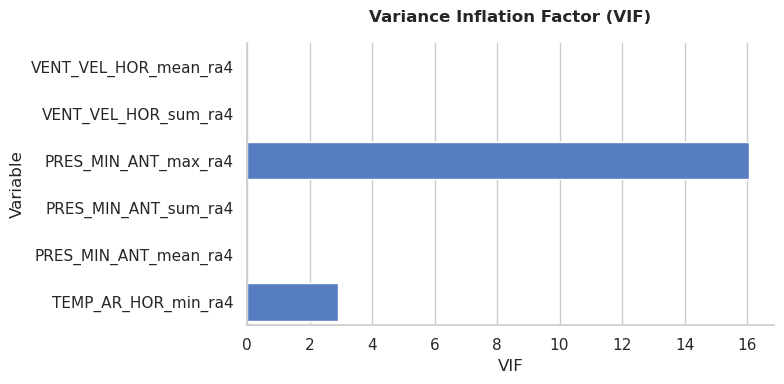

In [55]:
vif_df = calculate_vif(df_new[[
    'VENT_VEL_HOR_mean_ra4',
    'VENT_VEL_HOR_sum_ra4',
    'PRES_MIN_ANT_max_ra4',
    'PRES_MIN_ANT_sum_ra4',
    'PRES_MIN_ANT_mean_ra4',
    'TEMP_AR_HOR_min_ra4'
]])

plot_vif(vif_df, highlight="X")

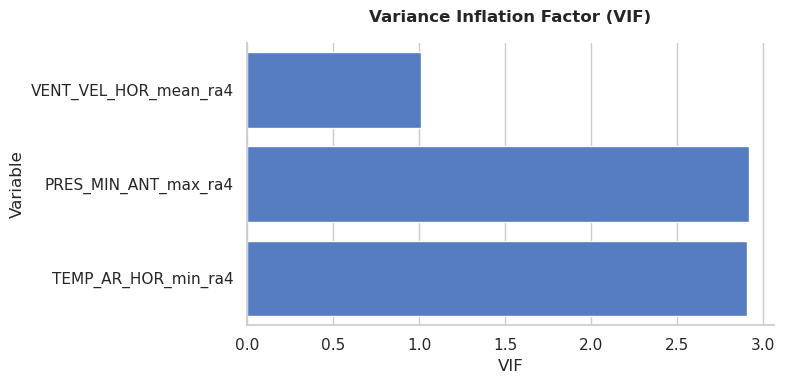

In [47]:

vif_df = calculate_vif(df_new[[
    'VENT_VEL_HOR_mean_ra4',
    #'VENT_VEL_HOR_sum_ra4',
    'PRES_MIN_ANT_max_ra4',
    #'PRES_MIN_ANT_sum_ra4',
    #'PRES_MIN_ANT_mean_ra4',
    'TEMP_AR_HOR_min_ra4'
]])

plot_vif(vif_df, highlight="X")

<Axes: xlabel='dt'>

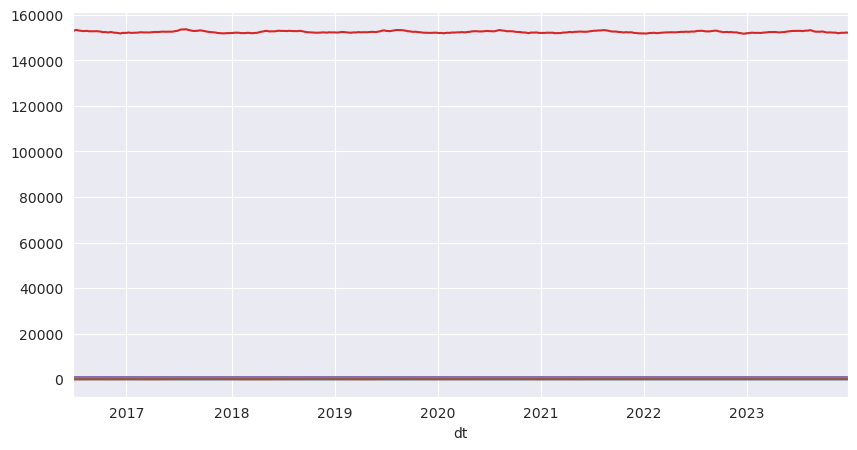

In [19]:

df_new['VENT_VEL_HOR_mean_ra4'].plot(label='VENT_VEL_HOR_mean_ra4', figsize=(10, 5))
df_new['VENT_VEL_HOR_sum_ra4'].plot(label='VENT_VEL_HOR_sum_ra4')
df_new['PRES_MIN_ANT_max_ra4'].plot(label='PRES_MIN_ANT_max_ra4')
df_new['PRES_MIN_ANT_sum_ra4'].plot(label='PRES_MIN_ANT_sum_ra4')
df_new['PRES_MIN_ANT_mean_ra4'].plot(label='PRES_MIN_ANT_mean_ra4')
df_new['TEMP_AR_HOR_min_ra4'].plot(label='TEMP_AR_HOR_min_ra4')



In [74]:
def lagged_correlation(df):

    interest_cols = ['Alface Crespa - Roça']
    shift_cols = df.columns.tolist()
    #shift_cols = ['RADIACAO GLOBAL (Kj/m²)_max']

    # with open('correlation/correlation.csv', 'w') as f:
    #     f.write('column,correlated_to,max_correlation\n')
    #
    for col in shift_cols:
        temp_df = pd.DataFrame()
        temp_df.index = df.index

        for i_col in interest_cols:
            temp_df[i_col] = df[i_col]

        temp_df[0] = df[col]
        for i in range(1, 110):
            temp_df[i] = temp_df[0].shift(i)
            temp_df = temp_df.copy()

        corr = temp_df.corr(method="spearman")
        corr = corr.iloc[1:]
        corr = corr[interest_cols]
        corr = corr[interest_cols].apply(lambda x: x.abs())
        max_corr = corr[interest_cols].max().values[0]
        corr.index.names = [f'Lag']
        corr.columns = [f'Corr. with {c}' for c in interest_cols]

        # legend = plt.legend()
        # legend.set_visible(False)
        plt.tight_layout()
        corr.plot(figsize=(10, 3), ylim=(0, 1), title=f'Correlação entre {col} e {interest_cols[0]}', grid=True, legend=False)

        # vertical_lines_1 = [i for i in range(0, 110, 26)]
        # for v in vertical_lines_1:
        #     plt.axvline(x = v, color = 'r', label = 'axvline - full height')
        #     plt.axvline(x = v+7, color = 'b', label = 'axvline - full height')
        #     plt.axvline(x = v+10, color = 'g', label = 'axvline - full height')

        # with open('correlation/correlation.csv', 'a') as f:
        #      f.write(f'\"{col}\",\"{interest_cols[0]}\",{max_corr}\n')

        plt.show()
        #plt.savefig(f'correlation/{col}.png', bbox_inches='tight')
        plt.close()


lagged_correlation(df_new[['Alface Crespa - Roça','VENT_VEL_HOR_mean_ra4']])

ValueError: Length of new names must be 1, got 2